# Football KPIs
Data sourced from `foot_etl.sqlite` — tables: `matches` (1930–2010), `wc2014`, `wc2022`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

DB = "foot_etl.sqlite"
con = sqlite3.connect(DB)
print("Connected to", DB)


Connected to foot_etl.sqlite


In [2]:
# ── Load tables ──────────────────────────────────────────────────────────────
matches = pd.read_sql("SELECT * FROM matches", con)
wc2014  = pd.read_sql("SELECT * FROM wc2014",  con)
wc2022  = pd.read_sql("SELECT * FROM wc2022",  con)

# Parse scores for matches (1930-2010): "4-1" → goals_team1=4, goals_team2=1
goals = matches["full_time_score"].str.extract(r"(\d+)-(\d+)").astype(float)
matches["goals_team1"] = goals[0]
matches["goals_team2"] = goals[1]
matches["total_goals"] = matches["goals_team1"] + matches["goals_team2"]
matches["year"] = matches["year"].astype(int)

# Parse year for wc2014
wc2014["year"] = 2014
wc2014["total_goals"] = wc2014["Home Team Goals"] + wc2014["Away Team Goals"]

# Parse for wc2022
wc2022["total_goals"] = wc2022["score_ft_home"] + wc2022["score_ft_away"]
wc2022["year"] = 2022

print(f"matches: {len(matches)} rows | wc2014: {len(wc2014)} rows | wc2022: {len(wc2022)} rows")


matches: 7299 rows | wc2014: 64 rows | wc2022: 64 rows


## KPI 1 — Goals per match over time (1930–2022)

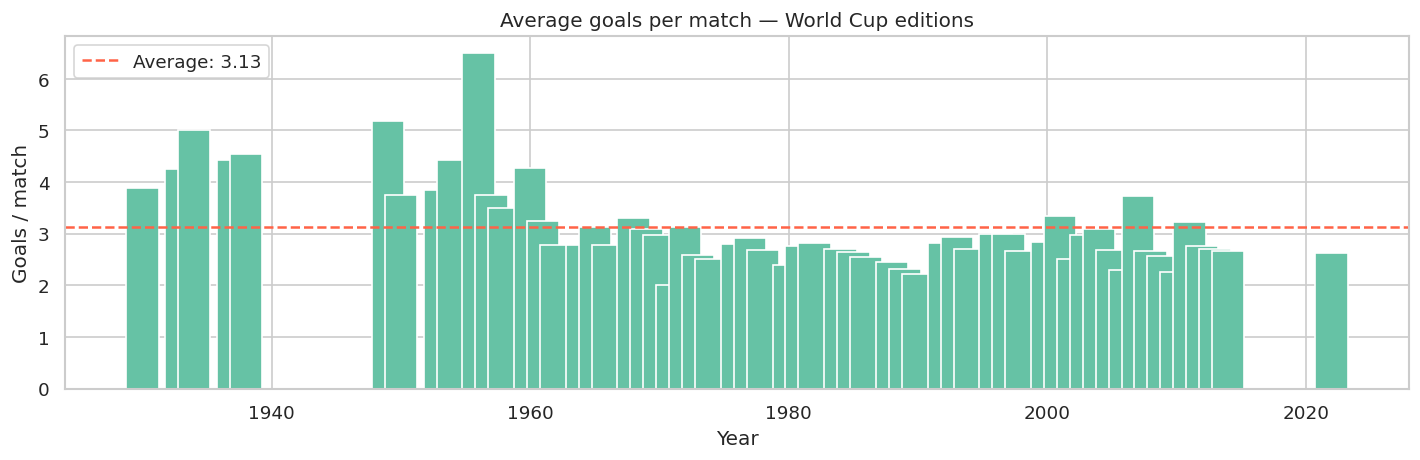

       goals  n_matches  goals_per_match
year                                    
1930    70.0         18         3.888889
1933    17.0          4         4.250000
1934   190.0         38         5.000000
1937    62.0         14         4.428571
1938   118.0         26         4.538462
1949   119.0         23         5.173913
1950   101.0         27         3.740741
1953   131.0         34         3.852941
1954   217.0         49         4.428571
1956    26.0          4         6.500000
1957   308.0         82         3.756098
1958   133.0         38         3.500000
1960   111.0         26         4.269231
1961   214.0         66         3.242424
1962    89.0         32         2.781250
1964    39.0         14         2.785714
1965   354.0        113         3.132743
1966    89.0         32         2.781250
1968   178.0         54         3.296296
1969   364.0        118         3.084746
1970    95.0         32         2.968750
1971     2.0          1         2.000000
1972   231.0    

In [3]:
gpm_hist = (
    matches.groupby("year")["total_goals"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "goals", "count": "n_matches"})
    .assign(goals_per_match=lambda d: d["goals"] / d["n_matches"])
)
gpm_2014 = pd.DataFrame([{"year": 2014,
                           "goals": wc2014["total_goals"].sum(),
                           "n_matches": len(wc2014),
                           "goals_per_match": wc2014["total_goals"].mean()}])
gpm_2022 = pd.DataFrame([{"year": 2022,
                           "goals": wc2022["total_goals"].sum(),
                           "n_matches": len(wc2022),
                           "goals_per_match": wc2022["total_goals"].mean()}])
gpm = pd.concat([gpm_hist.reset_index(), gpm_2014, gpm_2022]).set_index("year").sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(gpm.index, gpm["goals_per_match"], width=2.5, color=sns.color_palette("Set2")[0])
ax.axhline(gpm["goals_per_match"].mean(), color="tomato", linestyle="--", label=f"Average: {gpm['goals_per_match'].mean():.2f}")
ax.set(title="Average goals per match — World Cup editions",
       xlabel="Year", ylabel="Goals / match")
ax.legend()
plt.tight_layout()
plt.show()

print(gpm[["goals", "n_matches", "goals_per_match"]].to_string())


## KPI 2 — Top 15 teams by total goals scored (1930–2010)

/tmp/ipykernel_55834/3005072987.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, ax=ax, palette="Set2")


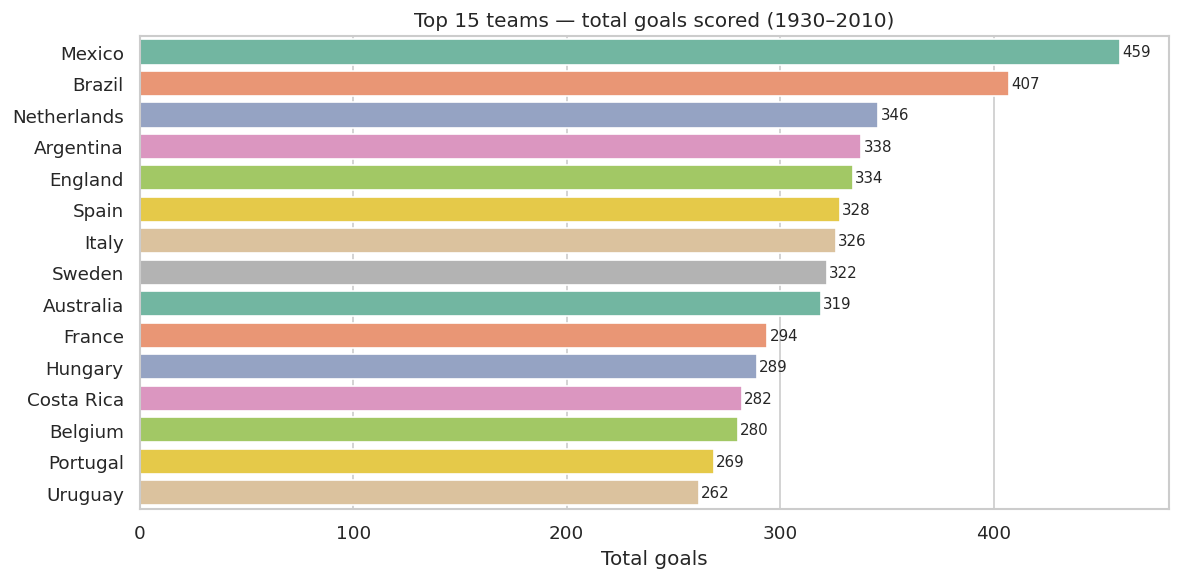

In [4]:
scored_as_t1 = matches.groupby("team1")["goals_team1"].sum().rename("goals")
scored_as_t2 = matches.groupby("team2")["goals_team2"].sum().rename("goals")
top_scorers = (
    pd.concat([scored_as_t1, scored_as_t2])
    .groupby(level=0).sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_scorers.values, y=top_scorers.index, ax=ax, palette="Set2")
ax.set(title="Top 15 teams — total goals scored (1930–2010)",
       xlabel="Total goals", ylabel="")
for i, v in enumerate(top_scorers.values):
    ax.text(v + 1, i, str(int(v)), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## KPI 3 — Win rate — top 10 teams (1930–2010)

/tmp/ipykernel_55834/3233670662.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10["win_rate"], y=top10.index, ax=axes[1], palette="Blues_r")


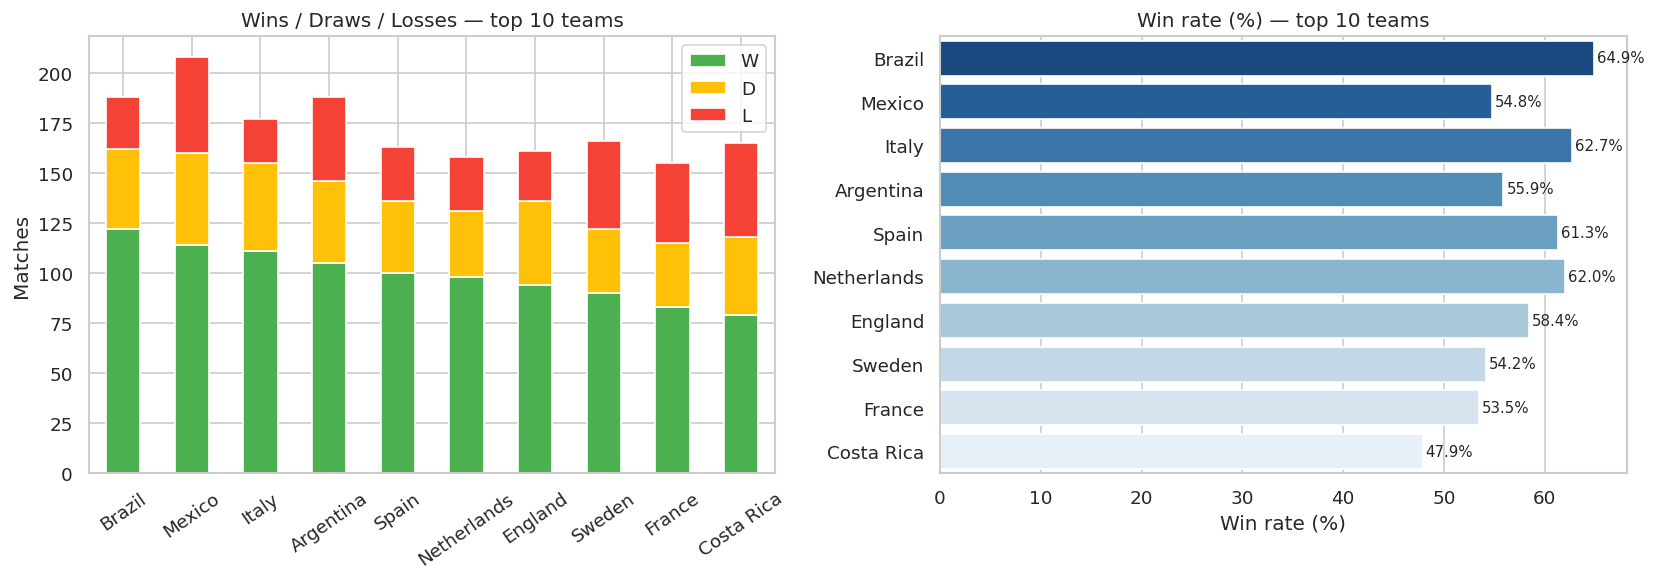

result         W   D   L  played  win_rate
team                                      
Brazil       122  40  26     188      64.9
Mexico       114  46  48     208      54.8
Italy        111  44  22     177      62.7
Argentina    105  41  42     188      55.9
Spain        100  36  27     163      61.3
Netherlands   98  33  27     158      62.0
England       94  42  25     161      58.4
Sweden        90  32  44     166      54.2
France        83  32  40     155      53.5
Costa Rica    79  39  47     165      47.9


In [5]:
def team_record(df):
    """Returns wins/draws/losses/matches played for each team."""
    records = []
    for _, row in df.iterrows():
        g1, g2 = row["goals_team1"], row["goals_team2"]
        if pd.isna(g1) or pd.isna(g2):
            continue
        if g1 > g2:
            records += [(row["team1"], "W"), (row["team2"], "L")]
        elif g1 < g2:
            records += [(row["team1"], "L"), (row["team2"], "W")]
        else:
            records += [(row["team1"], "D"), (row["team2"], "D")]
    return pd.DataFrame(records, columns=["team", "result"])

rec = team_record(matches)
kpi_wins = (
    rec.groupby(["team", "result"]).size().unstack(fill_value=0)
    .reindex(columns=["W", "D", "L"], fill_value=0)
)
kpi_wins["played"]   = kpi_wins.sum(axis=1)
kpi_wins["win_rate"] = (kpi_wins["W"] / kpi_wins["played"] * 100).round(1)

top10 = kpi_wins.nlargest(10, "W")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: W / D / L
top10[["W", "D", "L"]].plot(kind="bar", stacked=True, ax=axes[0],
                             color=["#4CAF50", "#FFC107", "#F44336"],
                             edgecolor="white")
axes[0].set(title="Wins / Draws / Losses — top 10 teams", xlabel="", ylabel="Matches")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(loc="upper right")

# Win rate
sns.barplot(x=top10["win_rate"], y=top10.index, ax=axes[1], palette="Blues_r")
axes[1].set(title="Win rate (%) — top 10 teams", xlabel="Win rate (%)", ylabel="")
for i, v in enumerate(top10["win_rate"]):
    axes[1].text(v + 0.3, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print(top10[["W", "D", "L", "played", "win_rate"]].to_string())


## KPI 4 — Attendance at 2014 World Cup

/tmp/ipykernel_55834/931566016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=att_by_city.values, y=att_by_city.index, ax=axes[0], palette="mako")
/tmp/ipykernel_55834/931566016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=att_by_stage.values, y=att_by_stage.index, ax=axes[1], palette="rocket")
/tmp/ipykernel_55834/931566016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=att_by_stage.values, y=att_by_stage.index, ax=axes[1], palette="rocket")


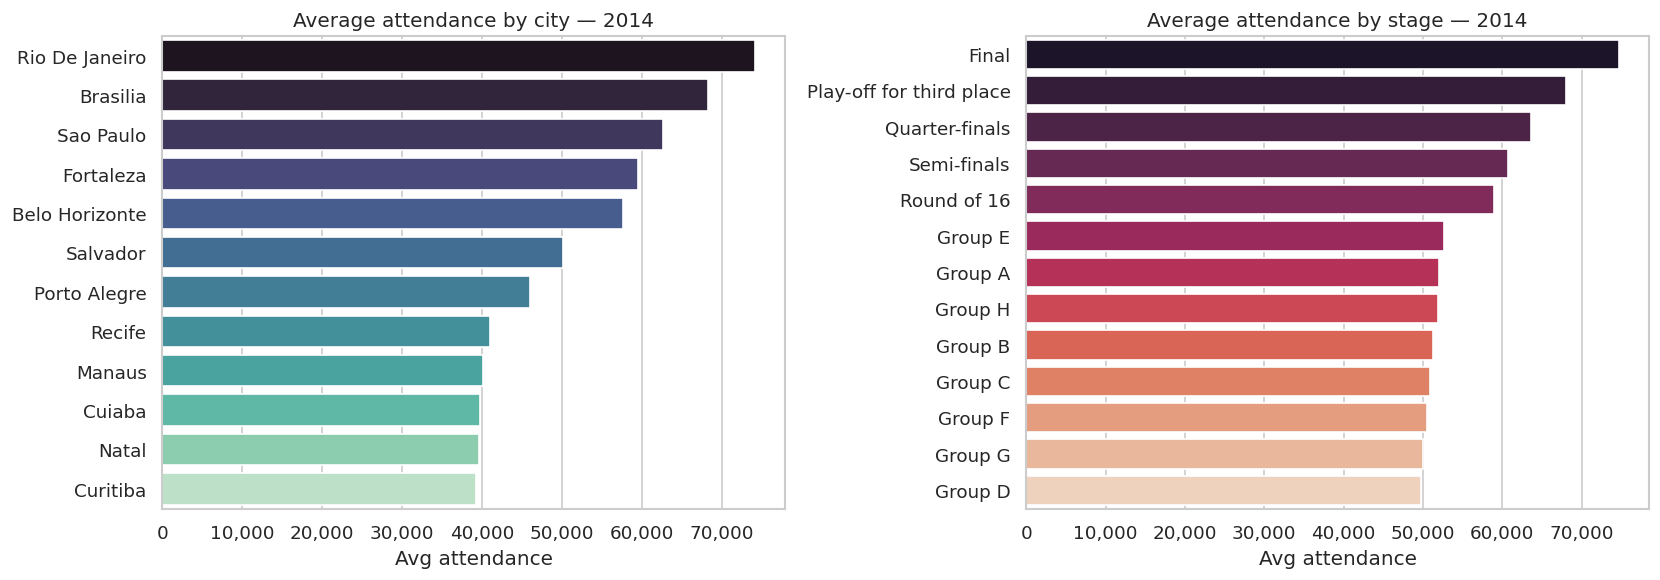

Total attendance 2014: 3,444,578
Average per match:     53,822


In [6]:
att_by_city = wc2014.groupby("City")["Attendance"].mean().sort_values(ascending=False)
att_by_stage = wc2014.groupby("Stage")["Attendance"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=att_by_city.values, y=att_by_city.index, ax=axes[0], palette="mako")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set(title="Average attendance by city — 2014", xlabel="Avg attendance", ylabel="")

sns.barplot(x=att_by_stage.values, y=att_by_stage.index, ax=axes[1], palette="rocket")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set(title="Average attendance by stage — 2014", xlabel="Avg attendance", ylabel="")

plt.tight_layout()
plt.show()

print(f"Total attendance 2014: {wc2014['Attendance'].sum():,.0f}")
print(f"Average per match:     {wc2014['Attendance'].mean():,.0f}")


## KPI 5 — 2022 World Cup: group stage goals & best goal difference

/tmp/ipykernel_55834/3039982088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=goals_by_group.index, y=goals_by_group.values, ax=axes[0], palette="Set2")


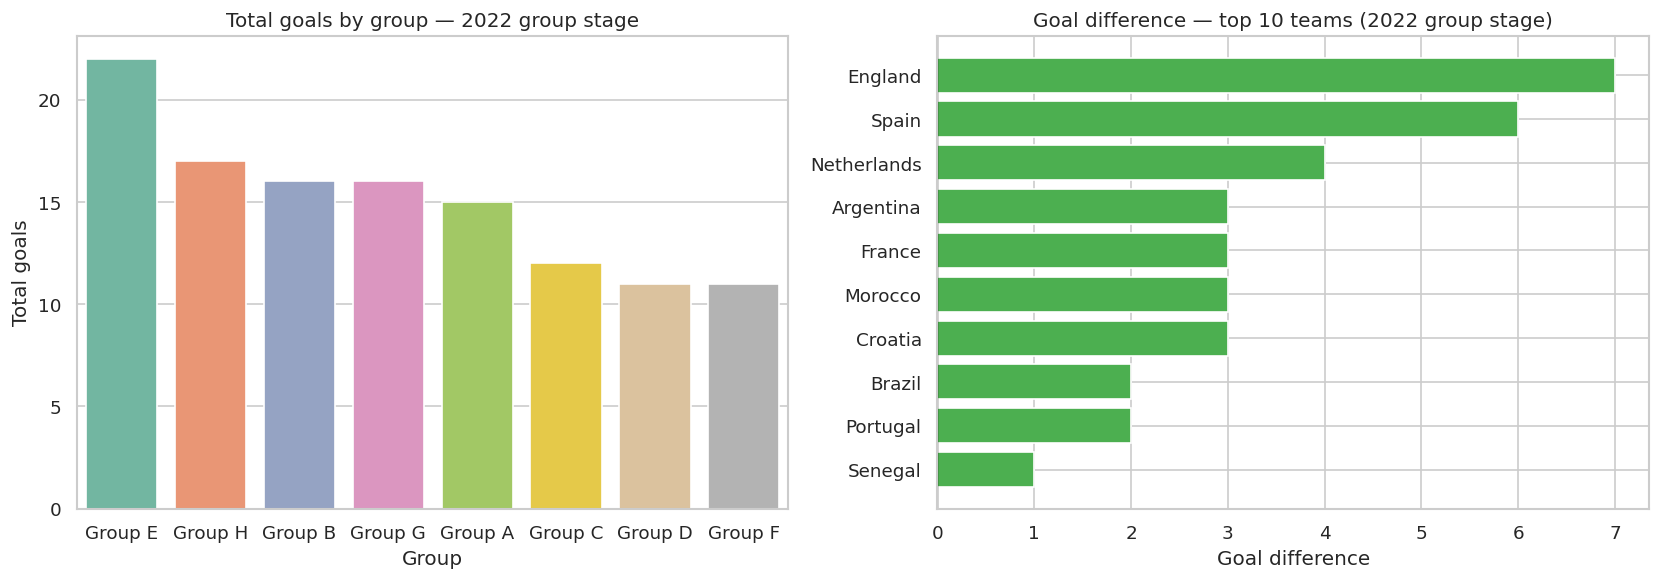

In [7]:
group_stage = wc2022[wc2022["group"].notna()].copy()

# Goals per group
goals_by_group = group_stage.groupby("group")["total_goals"].sum().sort_values(ascending=False)

# Goal difference per team
gf_t1 = group_stage.groupby("team1")["score_ft_home"].sum().rename("gf")
ga_t1 = group_stage.groupby("team1")["score_ft_away"].sum().rename("ga")
gf_t2 = group_stage.groupby("team2")["score_ft_away"].sum().rename("gf")
ga_t2 = group_stage.groupby("team2")["score_ft_home"].sum().rename("ga")

gf = pd.concat([gf_t1, gf_t2]).groupby(level=0).sum()
ga = pd.concat([ga_t1, ga_t2]).groupby(level=0).sum()
gd = (gf - ga).sort_values(ascending=False).head(10).rename("goal_diff")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=goals_by_group.index, y=goals_by_group.values, ax=axes[0], palette="Set2")
axes[0].set(title="Total goals by group — 2022 group stage",
            xlabel="Group", ylabel="Total goals")

colors = ["#4CAF50" if v >= 0 else "#F44336" for v in gd.values]
axes[1].barh(gd.index[::-1], gd.values[::-1], color=colors[::-1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(title="Goal difference — top 10 teams (2022 group stage)",
            xlabel="Goal difference", ylabel="")

plt.tight_layout()
plt.show()
